# Project 12 - Multimodal AI: Vision-Language Models

Multimodal models understand **images and text together** - answer questions about a photo, read a
chart, or extract fields from a scanned form. We build the *intuition* here with runnable NumPy
demos (image -> patch "tokens", a tiny working visual-question-answering function), then give you
the real open vision-language-model code for a Kaggle GPU.

**What you'll learn**
- How a model turns an **image into tokens** (patches), just like words.
- How image tokens and text tokens go into **one transformer** to answer questions.
- A toy but **working** visual-question-answering function you can run.

## The scenario
A bank wants to auto-read uploaded documents: "What's the total on this invoice?", "Is this form
signed?". A user wants "What breed is this dog?". All of these need a model that takes an **image +
a question** and returns an **answer** - a vision-language model (VLM).

## Foundations (plain English)
- **An image is numbers** (a grid of pixels; colour = 3 grids: R, G, B).
- **Patches as tokens:** a VLM chops the image into a grid of small **patches** and treats each
  patch like a word "token". So an image becomes a *sequence* of tokens, just like a sentence.
- **One shared transformer:** the patch tokens are projected into the same space as text tokens,
  then the image tokens and the question's word tokens are fed into one transformer, which attends
  across both to produce an answer.
- **Use cases:** visual Q&A, document/chart understanding, extracting structured data from images.

### Cell 1 - imports and a synthetic image
We draw a simple coloured shape on a white background so we know the 'right answers' and can test
our toy VLM. (Real projects use real photos/documents.)

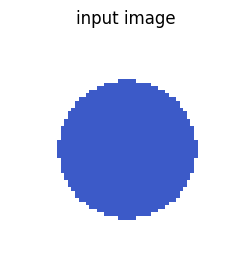

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def make_image(shape="circle", color=(60,90,200), size=64):
    img = np.ones((size,size,3))*255
    yy,xx = np.mgrid[0:size,0:size]; cx=cy=size/2
    if shape=="circle":
        mask = (xx-cx)**2 + (yy-cy)**2 <= (size*0.30)**2
    else:
        m=size*0.28; mask=(np.abs(xx-cx)<=m)&(np.abs(yy-cy)<=m)
    for c in range(3): img[...,c][mask]=color[c]
    return img.astype(np.uint8), mask

img, mask = make_image("circle", (60,90,200))     # a blue circle
plt.figure(figsize=(3,3)); plt.imshow(img); plt.title("input image"); plt.axis("off"); plt.show()

### Cell 2 - diagram: split the image into patches (= tokens)
A VLM divides the image into a grid of patches; each patch becomes one token. Here 64x64 with
16x16 patches = a 4x4 grid = 16 image tokens. The grid lines show the patch boundaries.

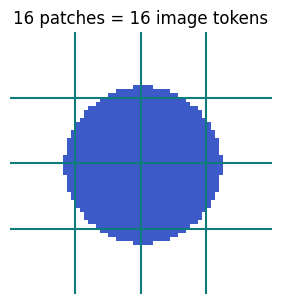

In [2]:
P, size = 16, 64
plt.figure(figsize=(3.4,3.4)); plt.imshow(img)
for k in range(P, size, P):
    plt.axhline(k-0.5, color="#0e7c7b"); plt.axvline(k-0.5, color="#0e7c7b")
plt.title(f"{(size//P)**2} patches = {(size//P)**2} image tokens"); plt.axis("off"); plt.show()

### Cell 3 - turn each patch into a number vector ('image tokens')
A real VLM runs each patch through a vision encoder. We use a simple stand-in: the average colour
of each patch. The image becomes a sequence of vectors - exactly the shape a transformer eats.

In [3]:
patches = img.reshape(size//P, P, size//P, P, 3).mean(axis=(1,3))   # (4,4,3) average colour
image_tokens = patches.reshape(-1, 3)                                # (16, 3): 16 tokens, 3 features
print("image is now a sequence of", image_tokens.shape[0], "tokens, each a vector of length", image_tokens.shape[1])
print("first 3 image tokens (avg R,G,B):\n", image_tokens[:3].round(0))

image is now a sequence of 16 tokens, each a vector of length 3
first 3 image tokens (avg R,G,B):
 [[255. 255. 255.]
 [243. 245. 252.]
 [241. 243. 251.]]


### Cell 4 - diagram: how a VLM answers (image tokens + text tokens -> transformer)
The image tokens and the question's word tokens are concatenated and fed into one transformer,
which attends across both modalities to produce the answer.

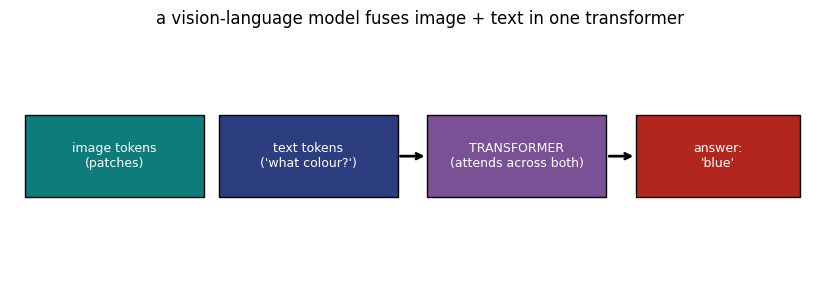

In [4]:
fig, ax = plt.subplots(figsize=(8.5,3)); ax.axis("off"); ax.set_xlim(0,11); ax.set_ylim(0,3)
def box(x,w,t,c): ax.add_patch(plt.Rectangle((x,1),w,1,facecolor=c,edgecolor="black")); ax.text(x+w/2,1.5,t,ha="center",va="center",color="white",fontsize=9)
box(0.2,2.4,"image tokens\n(patches)","#0e7c7b")
box(2.8,2.4,"text tokens\n('what colour?')","#2d3e80")
box(5.6,2.4,"TRANSFORMER\n(attends across both)","#7a5195")
box(8.4,2.2,"answer:\n'blue'","#b3261e")
ax.annotate("",(5.6,1.5),(5.2,1.5),arrowprops=dict(arrowstyle="->",lw=2))
ax.annotate("",(8.4,1.5),(8.0,1.5),arrowprops=dict(arrowstyle="->",lw=2))
ax.set_title("a vision-language model fuses image + text in one transformer"); plt.tight_layout(); plt.show()

### Cell 5 - a tiny but WORKING visual-Q&A function
To make VLM input/output concrete, we answer real questions about the image with simple image
analysis: the dominant colour of the shape, and whether it's a square or a circle (squares fill
their bounding box; circles fill ~78% of it).

In [5]:
def answer_color(img, mask):
    avg = img[mask].mean(0)
    names = {"red":(200,40,40), "green":(40,160,40), "blue":(60,90,200)}
    return min(names, key=lambda n: np.linalg.norm(avg-np.array(names[n])))

def answer_shape(mask):
    ys, xs = np.where(mask)
    bbox = (ys.max()-ys.min()+1) * (xs.max()-xs.min()+1)
    fill = mask.sum() / bbox          # square ~1.0, circle ~0.785
    return "square" if fill > 0.9 else "circle"

print("Q: What colour is the shape? A:", answer_color(img, mask))
print("Q: What shape is it?        A:", answer_shape(mask))

Q: What colour is the shape? A: blue
Q: What shape is it?        A: circle


### Cell 6 - diagram: the answer, on the image
Our toy VLM reads the picture and answers - the same input/output a real VLM gives, just with a
simpler 'brain'.

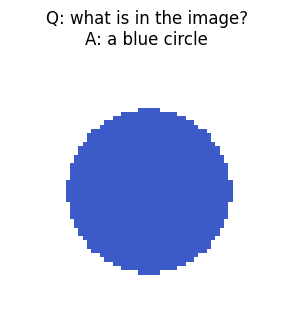

In [6]:
plt.figure(figsize=(3.2,3.4)); plt.imshow(img)
plt.title(f"Q: what is in the image?\nA: a {answer_color(img,mask)} {answer_shape(mask)}")
plt.axis("off"); plt.tight_layout(); plt.show()

## The real thing - an open VLM on a Kaggle GPU
Swap our toy analyser for a real pretrained vision-language model. It handles photos, documents,
and charts, not just coloured shapes.

```python
# pip install transformers accelerate pillow  (preinstalled on Kaggle)
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image

model_id = "Qwen/Qwen2-VL-2B-Instruct"                 # a small open vision-language model
proc  = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(model_id, device_map="auto")

image = Image.open("invoice.png")
messages = [{"role":"user","content":[
    {"type":"image"}, {"type":"text","text":"What is the total amount on this invoice?"}]}]
prompt = proc.apply_chat_template(messages, add_generation_prompt=True)
inputs = proc(images=image, text=prompt, return_tensors="pt").to(model.device)
print(proc.decode(model.generate(**inputs, max_new_tokens=100)[0], skip_special_tokens=True))
```

**Make it a project:** build a labelled eval set (image + question -> answer), measure accuracy,
validate outputs against a JSON schema (Project 09 guardrails), and deploy a **Gradio Space**:
```python
import gradio as gr
def vqa(image, question): ...      # run the model
gr.Interface(vqa, [gr.Image(type="pil"), "text"], "text").launch()
```

## What just happened (recap)
- An image becomes a **sequence of patch tokens** (you saw the 4x4 grid and the token vectors).
- Image tokens + text tokens go into **one transformer** that attends across both to answer.
- A toy VQA function actually answered "blue" and "circle" - the same I/O shape as a real VLM,
  which you'd run on a Kaggle GPU.

## Extensions
- **Change the image:** call `make_image('square', (200,40,40))` and re-run - the VQA should say
  'red square'.
- **Harder questions:** real VLMs handle 'how many?', 'read this text', 'is it signed?'.
- **Documents/charts:** the biggest enterprise value is reading invoices, forms, and charts.
- **Project goal:** run an open VLM on a real image set, evaluate accuracy, and ship a Space.

## Mini-glossary
**multimodal** more than one input type - **VLM** vision-language model - **patch** a small image
square treated as a token - **image encoder** turns patches into vectors - **projection** maps image
vectors into the text token space - **visual question answering (VQA)** answer a question about an
image - **document understanding** extract structure from document images.